# **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.linear_model import ElasticNet
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import scipy
import seaborn as sns
import matplotlib.pyplot as plt

# Load the datasets from the CSV files

In [3]:
dataset1 = pd.read_csv('/content/Series 5000.csv')

In [4]:
dataset1.head()

,ID,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%),2% proof stress (Mpa),Tensile strength (Mpa),Elongation (%)
0,A 5005 P,1,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,95,125,2
1,A 5005 P,1,4,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,120,145,2
2,A 5005 P,1,6,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,145,165,2
3,A 5005 P,1,8,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,165,185,2
4,A 5005 P,2,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125,85,120,4


In [5]:
dataset1.drop("ID", axis=1, inplace=True)
dataset1.columns

Index(['X', 'n', 'Fe (wt%)', 'Mn (wt%)', 'Si (wt%)', 'Al (wt%)', 'Mg (wt%)',
       'Ti (wt%)', 'Cu (wt%)', 'Cr (wt%)', 'Zn (wt%)', '2% proof stress (Mpa)',
       'Tensile strength (Mpa)', 'Elongation (%)'],
      dtype='object')

In [6]:
X = dataset1.drop(['2% proof stress (Mpa)', 'Tensile strength (Mpa)', 'Elongation (%)'], axis=1)
strength = dataset1['Tensile strength (Mpa)']  # Change the target variable as needed

In [7]:
X.head()

,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%)
0,1,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
1,1,4,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
2,1,6,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
3,1,8,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125
4,2,2,0.35,0.1,0.15,98.33,0.8,0.0,0.1,0.05,0.125


# Split the data into training and testing sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, strength, test_size=0.2, random_state=42)
print(f"The Shape of X_train : {X_train.shape}")
print(f"The Shape of X_test : {X_test.shape}")
print(f"The Shape of y_train : {y_train.shape}")
print(f"The Shape of y_test : {y_test.shape}")


The Shape of X_train : (92, 11)
The Shape of X_test : (23, 11)
The Shape of y_train : (92,)
The Shape of y_test : (23,)


In [10]:
X.describe()

,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%)
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,1.930435,4.547826,0.233391,0.152696,0.169304,96.461739,2.655217,0.038000,0.060957,0.152000,0.088609
std,0.895620,2.414298,0.060406,0.169671,0.043199,1.242349,1.158007,0.040614,0.026917,0.089904,0.034051
min,1.000000,1.000000,0.130000,0.010000,0.080000,94.250000,0.400000,0.000000,0.020000,0.000000,0.015000
25%,1.000000,2.000000,0.200000,0.050000,0.130000,95.630000,2.050000,0.000000,0.050000,0.050000,0.050000
50%,2.000000,4.000000,0.200000,0.050000,0.200000,96.780000,2.500000,0.030000,0.050000,0.150000,0.100000
75%,3.000000,6.000000,0.250000,0.275000,0.200000,96.900000,3.500000,0.080000,0.080000,0.250000,0.125000
max,4.000000,9.000000,0.350000,0.750000,0.230000,99.190000,5.050000,0.100000,0.100000,0.250000,0.125000


In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         115 non-null    int64  
 1   n         115 non-null    int64  
 2   Fe (wt%)  115 non-null    float64
 3   Mn (wt%)  115 non-null    float64
 4   Si (wt%)  115 non-null    float64
 5   Al (wt%)  115 non-null    float64
 6   Mg (wt%)  115 non-null    float64
 7   Ti (wt%)  115 non-null    float64
 8   Cu (wt%)  115 non-null    float64
 9   Cr (wt%)  115 non-null    float64
 10  Zn (wt%)  115 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 10.0 KB


## **Initialize the models**

In [12]:
linear_regression_model = LinearRegression()
ent = ElasticNet()
random_forest_model = RandomForestRegressor()
alpha_value = 1.0  # You can adjust this value based on your needs
ridge_model = Ridge(alpha=alpha_value)
svm_model = SVC(kernel='linear')
gpr_model = GaussianProcessRegressor()


## **Train the models**


In [13]:
ent.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
linear_regression_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
gpr_model.fit(X_train, y_train)

GaussianProcessRegressor()

In [14]:
X_test.head()

,X,n,Fe (wt%),Mn (wt%),Si (wt%),Al (wt%),Mg (wt%),Ti (wt%),Cu (wt%),Cr (wt%),Zn (wt%)
81,2,4,0.23,0.01,0.23,95.65,3.50,0.03,0.03,0.25,0.100
4,2,2,0.35,0.10,0.15,98.33,0.80,0.00,0.10,0.05,0.125
40,3,8,0.20,0.13,0.15,94.25,5.05,0.00,0.05,0.13,0.050
69,2,2,0.25,0.30,0.20,96.90,2.05,0.08,0.08,0.08,0.075
10,1,9,0.18,0.35,0.10,95.58,3.50,0.05,0.08,0.05,0.125


## **Predict the target variable for the test set**

In [15]:
y_pred_linear_regression = linear_regression_model.predict(X_test)
y_pred_elastic_net = ent.predict(X_test)
y_pred_random_forest = random_forest_model.predict(X_test)
y_pred_ridge_model = ridge_model.predict(X_test)
y_pred_svm_model = svm_model.predict(X_test)
y_pred_gpr_model = gpr_model.predict(X_test)

In [16]:
y_pred_linear_regression

array([274.57612696, 129.49681559, 368.58348715, 181.14973355,
       323.54457361, 296.01703003, 205.29732368, 204.39394339,
       272.77282019, 264.07897858, 265.74696654, 294.33395616,
       275.47950726, 131.79263809, 170.72534898, 128.5934353 ,
       182.05311385, 231.93526872, 302.09154061, 267.27483474,
       288.08779608, 107.64504795, 133.60058348])

In [17]:
y_pred_elastic_net

array([264.97541597, 150.68180988, 358.49826539, 197.41801986,
       316.0926775 , 290.31076096, 217.93372424, 216.65492693,
       271.07385389, 266.08221387, 249.64622014, 294.39355765,
       266.25421327, 150.3416709 , 193.82620843, 149.40301257,
       198.69681717, 226.57292115, 293.75525648, 264.05205279,
       267.6043299 , 129.82596652, 161.77385456])

In [18]:
y_pred_random_forest

array([275.45, 156.55, 356.25, 195.4 , 330.95, 296.45, 223.85, 221.15,
       271.05, 281.8 , 290.25, 271.25, 276.  , 133.  , 175.2 , 146.5 ,
       196.95, 236.2 , 287.2 , 274.  , 290.6 , 123.  , 156.95])

In [19]:
y_pred_ridge_model

array([271.10637584, 131.82841533, 374.82813933, 188.95900454,
       323.54187452, 297.60649859, 211.81798458, 210.65446568,
       275.91103745, 267.55794332, 253.46291569, 303.92416141,
       272.26989474, 133.41477605, 180.64419686, 130.66489643,
       190.12252344, 228.03901534, 300.77750343, 270.34334815,
       273.99485793, 110.55579601, 145.1922079 ])

In [20]:
y_pred_svm_model

array([275, 155, 370, 215, 315, 275, 235, 235, 275, 275, 235, 275, 275,
       160, 180, 155, 215, 235, 315, 275, 270, 110, 155])

In [21]:
y_pred_gpr_model

array([268.95318944, 106.28398589, 227.72787757, 211.76705368,
       241.48478778, 255.50681315, 232.00202048, 197.20761796,
       258.90959084, 260.9865505 , 277.77246087, 113.26900488,
       265.64985078,  89.54414267, 204.00374837, 104.40237088,
       204.55499884, 223.65643394, 311.07410687, 274.03680137,
       275.76481302,  39.06720663,  84.09796812])

## **Calculate the evaluation metrics**

In [22]:
mse_linear_regression = mean_squared_error(y_test, y_pred_linear_regression)
mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
mse_random_forest = mean_squared_error(y_test, y_pred_random_forest)
mse_ridge_model = mean_squared_error(y_test, y_pred_ridge_model)
mse_svm_model = mean_squared_error(y_test, y_pred_svm_model)
mse_gpr_model = mean_squared_error(y_test, y_pred_gpr_model)


print(mse_linear_regression)
print(mse_elastic_net)
print(mse_random_forest)
print(mse_ridge_model)
print(mse_svm_model)
print(mse_gpr_model)

220.52327494984115
358.83802195527375
182.9773913043479
235.5796944873984
581.5217391304348
3529.3173607305253


In [23]:
rmse_linear_regression = mean_squared_error(y_test, y_pred_linear_regression, squared=False)
rmse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net, squared=False)
rmse_random_forest = mean_squared_error(y_test, y_pred_random_forest, squared=False)
rmse_ridge_model =  mean_squared_error(y_test, y_pred_ridge_model, squared=False)
rmse_svm_model = mean_squared_error(y_test, y_pred_svm_model, squared=False)
rmse_gpr_model = mean_squared_error(y_test, y_pred_gpr_model, squared=False)


print(rmse_linear_regression)
print(rmse_elastic_net)
print(rmse_random_forest)
print(rmse_ridge_model)
print(rmse_svm_model)
print(rmse_gpr_model)

14.85002609256432
18.943020402123672
13.526913591220573
15.348605620296535
24.114761850999788
59.40805804544132


In [24]:
r2_linear_regression = r2_score(y_test, y_pred_linear_regression)
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)
r2_random_forest = r2_score(y_test, y_pred_random_forest)
r2_ridge_model =  r2_score(y_test, y_pred_ridge_model)
r2_svm_model =  r2_score(y_test, y_pred_svm_model)
r2_gpr_model =  r2_score(y_test, y_pred_gpr_model)

print(r2_linear_regression)
print(r2_random_forest)
print(r2_ridge_model)
print(r2_svm_model)
print(r2_gpr_model)

0.9570751692797344
0.9643834713176583
0.9541444389064894
0.886806858740847
0.3130187718193883


## **Create a dictionary to store the evaluation metrics**

In [25]:
metrics = {
    'Linear Regression': {'MSE': mse_linear_regression, 'R2 Score': r2_linear_regression},
    'Elastic Net': {'MSE': mse_elastic_net, 'R2 Score': r2_elastic_net},
    'Random Forest': {'MSE': mse_random_forest, 'R2 Score': r2_random_forest},
    'Ridge Regression': {'MSE': mse_ridge_model, 'R2 Score': r2_ridge_model},
    'Support Vector Machine': {'MSE': mse_svm_model, 'R2 Score': r2_svm_model},
    'Gaussian Process Regression': {'MSE': mse_gpr_model, 'R2 Score': r2_gpr_model}
}

## **Plot the evaluation metrics**

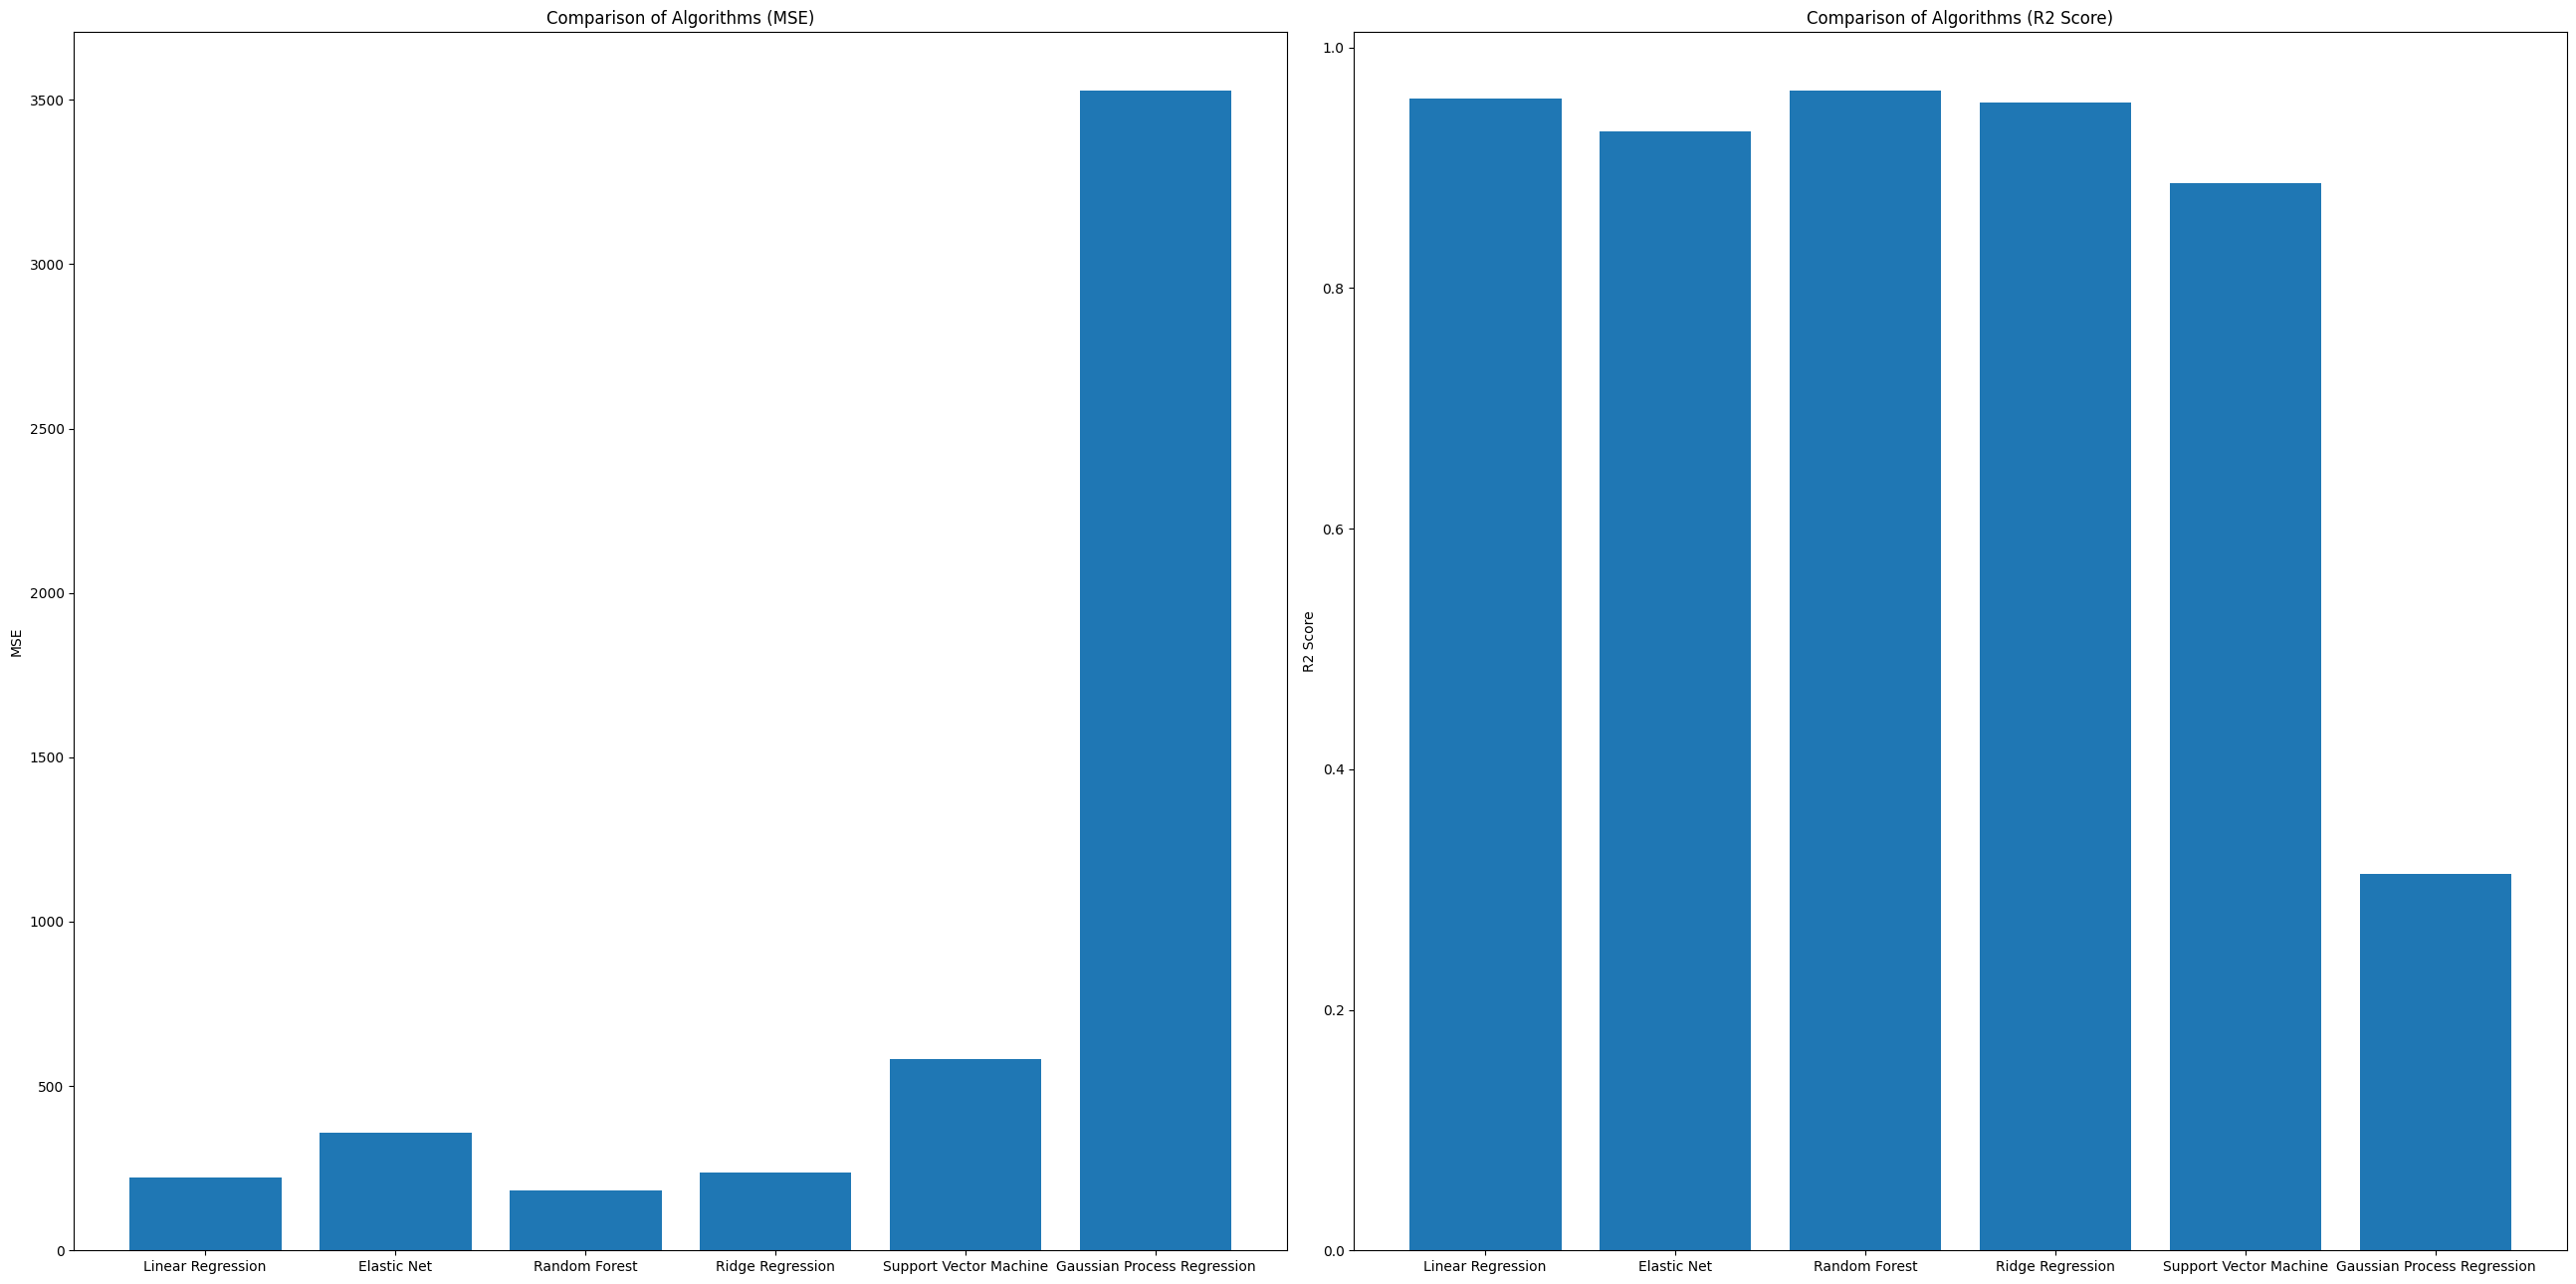

In [26]:
metric_names = ['MSE', 'R2 Score']
num_algorithms = len(metrics)

plt.figure(figsize=(26, 13))

for i, metric in enumerate(metric_names):
    plt.subplot(1, 2, i+1)
    metric_values = [metrics[algorithm][metric] for algorithm in metrics]
    plt.bar(range(num_algorithms), metric_values)
    plt.xticks(range(num_algorithms), metrics.keys())
    plt.ylabel(metric)
    plt.title(f'Comparison of Algorithms ({metric})')

plt.tight_layout()
plt.show()

In [27]:
print('Linear Regression')
print('MSE:', metrics['Linear Regression']['MSE'])
print('R2 Score:', metrics['Linear Regression']['R2 Score'])
print()

Linear Regression
MSE: 220.52327494984115
R2 Score: 0.9570751692797344



In [28]:
print('Ridge Regression')
print('MSE:', metrics['Ridge Regression']['MSE'])
print('R2 Score:', metrics['Ridge Regression']['R2 Score'])

Ridge Regression
MSE: 235.5796944873984
R2 Score: 0.9541444389064894


In [29]:
print('Elastic Net')
print('MSE:', metrics['Elastic Net']['MSE'])
print('R2 Score:', metrics['Elastic Net']['R2 Score'])
print()

Elastic Net
MSE: 358.83802195527375
R2 Score: 0.9301522192978107



In [30]:
print('Support Vector Machine')
print('MSE:', metrics['Support Vector Machine']['MSE'])
print('R2 Score:', metrics['Support Vector Machine']['R2 Score'])

Support Vector Machine
MSE: 581.5217391304348
R2 Score: 0.886806858740847


In [31]:
print('Random Forest')
print('MSE:', metrics['Random Forest']['MSE'])
print('R2 Score:', metrics['Random Forest']['R2 Score'])

Random Forest
MSE: 182.9773913043479
R2 Score: 0.9643834713176583


In [32]:
print('Gaussian Process Regression')
print('MSE:', metrics['Gaussian Process Regression']['MSE'])
print('R2 Score:', metrics['Gaussian Process Regression']['R2 Score'])

Gaussian Process Regression
MSE: 3529.3173607305253
R2 Score: 0.3130187718193883






## **Graph Plotting**



In [33]:
strength = dataset1['Tensile strength (Mpa)']

x = dataset1['X']
n = dataset1['n']
Fe = dataset1['Fe (wt%)']
Mn = dataset1['Mn (wt%)']
Si = dataset1['Si (wt%)']
Al = dataset1['Al (wt%)']
Mg = dataset1['Mg (wt%)']
Ti = dataset1['Ti (wt%)']
Cu = dataset1['Cu (wt%)']
Cr = dataset1['Cr (wt%)']
Zn = dataset1['Zn (wt%)']

In [34]:
dataset= pd.read_csv('/content/Series 5000.csv')

id= dataset['ID']

In [35]:
sns.set_style("ticks")

In [36]:
from google.colab import files

In [37]:
x = dataset1['X']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.14134205581663795


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

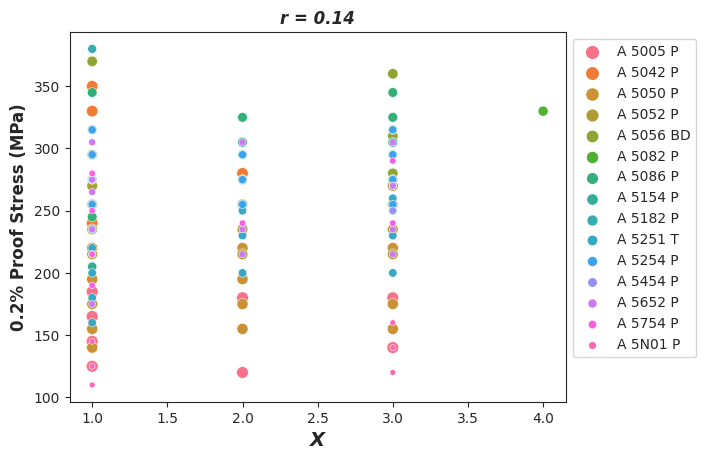

In [40]:
sns.scatterplot(x= dataset1['X'], y= dataset['Tensile strength (Mpa)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('X', fontdict={'size': 14, 'weight': 'bold', 'style': 'italic'})
plt.ylabel('0.2% Proof Stress (MPa)', fontdict={'size': 12 , 'weight': 'bold'})
plt.title('r = 0.14', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('X vs Tensile Strength (MPa).pdf')
files.download('X vs Tensile Strength (MPa).pdf')
plt.show

In [43]:
x = dataset1['n']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.5139234529619845


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

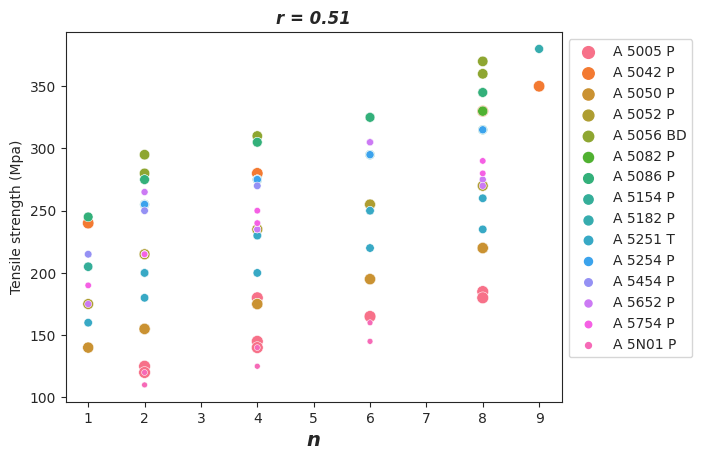

In [44]:
sns.scatterplot(x=dataset1['n'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('n', fontdict={'size': 14, 'weight': 'bold', 'style': 'italic'})
plt.title('r = 0.51', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('n vs Tensile Strength (Mpa).pdf')
files.download('n vs Tensile Strength (Mpa).pdf')
plt.show

In [45]:
x = dataset1['Fe (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.35495208644696313


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

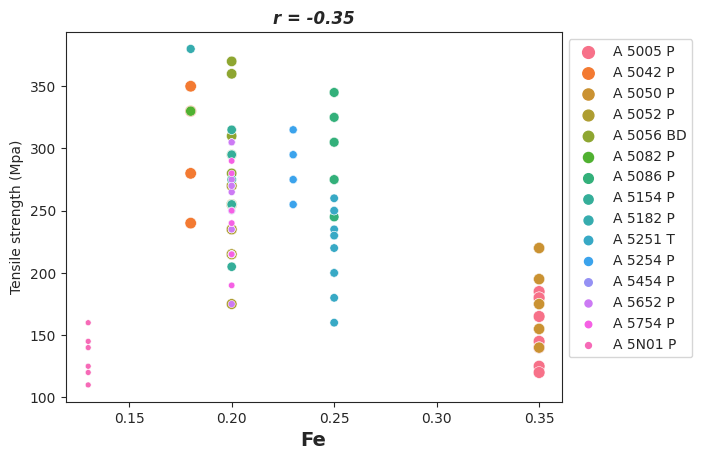

In [46]:
sns.scatterplot(x=dataset1['Fe (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Fe', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = -0.35', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Fe vs Tensile Strength (Mpa).pdf')
files.download('Fe vs Tensile Strength (Mpa).pdf')
plt.show

In [47]:
x = dataset1['Mn (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.18574183481255718


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

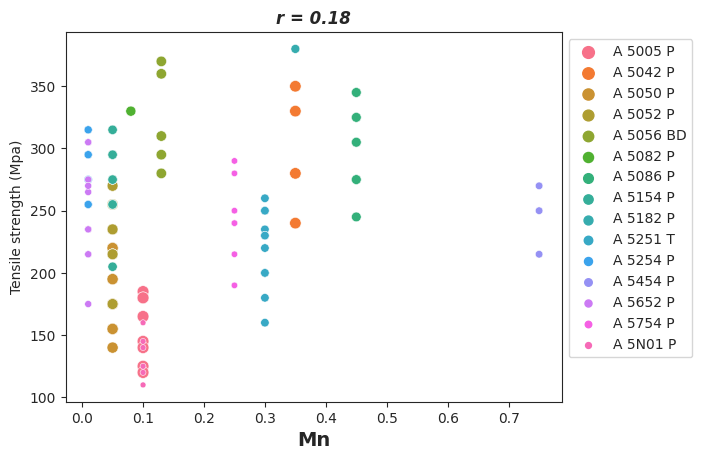

In [48]:
sns.scatterplot(x=dataset1['Mn (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Mn', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.18', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Mn vs Tensile Strength (Mpa).pdf')
files.download('Mn vs Tensile Strength (Mpa).pdf')
plt.show

In [49]:
x = dataset1['Si (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.12064254309734876


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

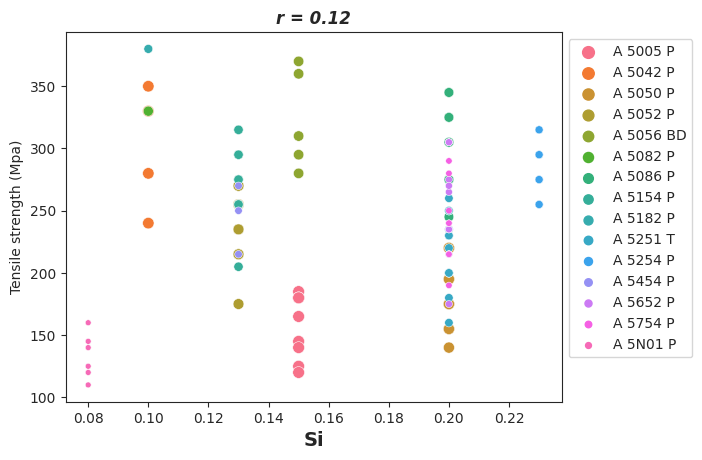

In [50]:
sns.scatterplot(x=dataset1['Si (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Si', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.12', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Si vs Tensile Strength (Mpa).pdf')
files.download('Si vs Tensile Strength (Mpa).pdf')
plt.show

In [51]:
x = dataset1['Al (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.8425016190418679


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

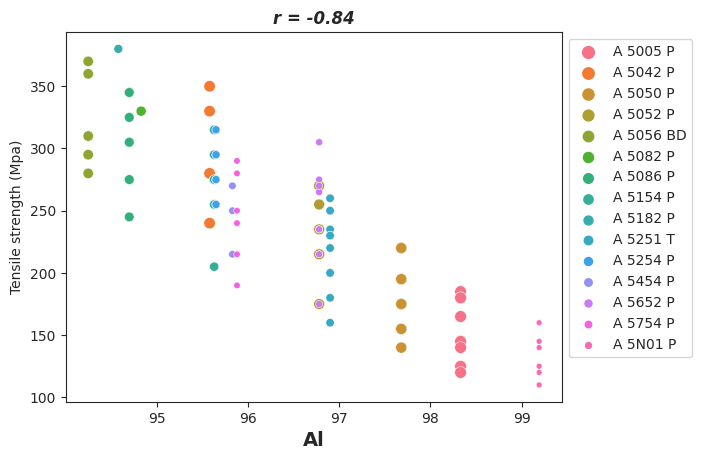

In [52]:
sns.scatterplot(x=dataset1['Al (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1, size = id)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Al', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = -0.84', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Al vs Tensile Strength (Mpa).pdf')
files.download('Al vs Tensile Strength (Mpa).pdf')
plt.show

In [53]:
x = dataset1['Mg (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.8525398146368874


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

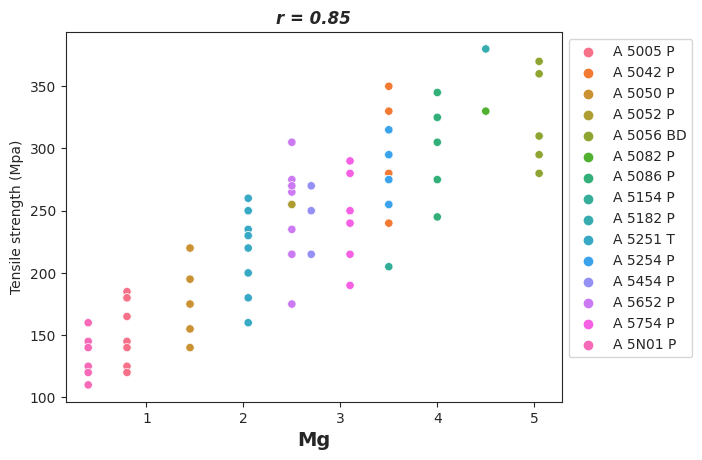

In [54]:
sns.scatterplot(x=dataset1['Mg (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Mg', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.85', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Mg vs Tensile Strength (Mpa).pdf')
files.download('Mg vs Tensile Strength (Mpa).pdf')
plt.show

In [55]:
x = dataset1['Ti (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.35747001076137014


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

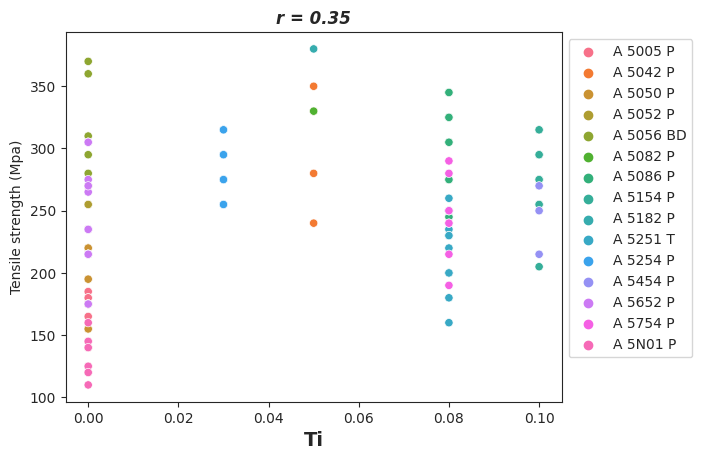

In [56]:
sns.scatterplot(x=dataset1['Ti (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Ti', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.35', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Ti vs Tensile Strength (Mpa).pdf')
files.download('Ti vs Tensile Strength (Mpa).pdf')
plt.show

In [57]:
x = dataset1['Cu (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]
print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): -0.5941915541482629


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

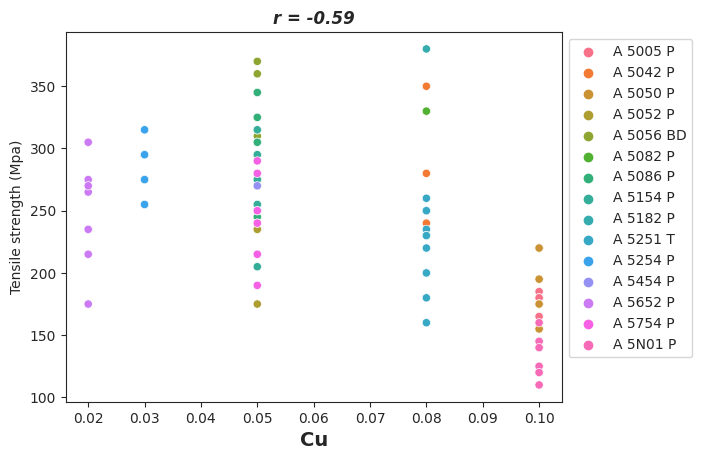

In [58]:
sns.scatterplot(x=dataset1['Cu (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Cu', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = -0.59', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Cu vs Tensile Strength (Mpa).pdf')
files.download('Cu vs Tensile Strength (Mpa).pdf')
plt.show

In [59]:
x = dataset1['Cr (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]

print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.4783782430802699


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

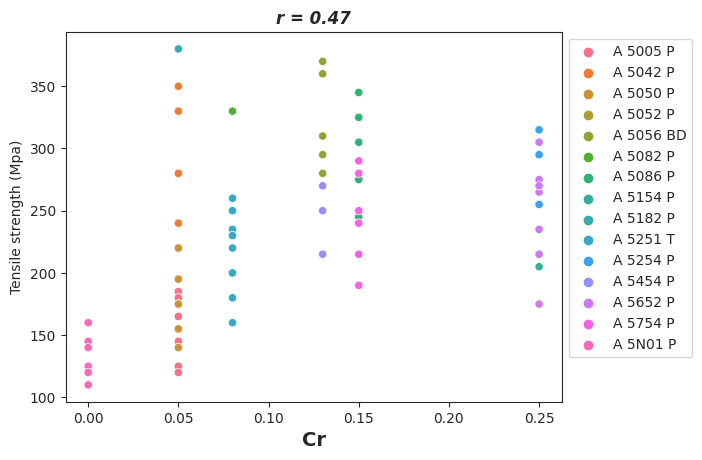

In [61]:
sns.scatterplot(x=dataset1['Cr (wt%)'], y=dataset1['Tensile strength (Mpa)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Cr', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.47', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Cr vs Tensile Strength (Mpa).pdf')
files.download('Cr vs Tensile Strength (Mpa).pdf')
plt.show

In [62]:
x = dataset1['Zn (wt%)']
value_to_append = x.tolist()
emptyarray = np.empty(0)
l1 = np.append(emptyarray, value_to_append)
strength = dataset1['Tensile strength (Mpa)']
value_to_append = strength.tolist()
emptyarray = np.empty(0)
l2 = np.append(emptyarray, value_to_append)
x = l1
y = l2
correlation_coefficient = np.corrcoef(x, y)[0, 1]

print("Correlation Coefficient (r):", correlation_coefficient)

Correlation Coefficient (r): 0.125960714419876


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<function matplotlib.pyplot.show(close=None, block=None)>

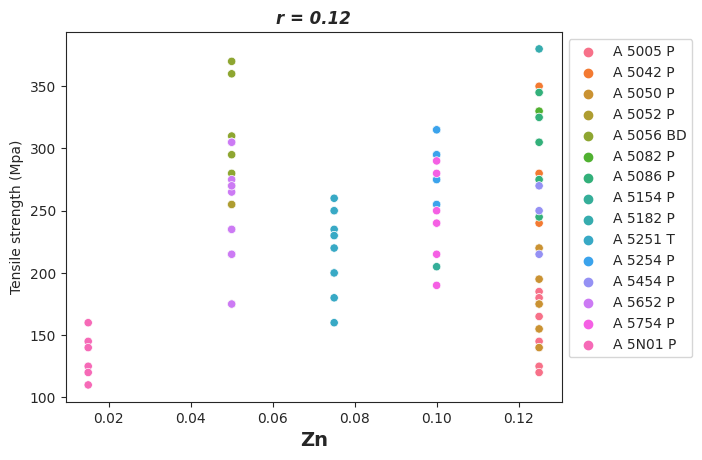

In [64]:
sns.scatterplot(x=dataset1['Zn (wt%)'], y=dataset['Tensile strength (Mpa)'], hue=id, data=dataset1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('Zn', fontdict={'size': 14, 'weight': 'bold'})
plt.title('r = 0.12', fontdict={'weight': 'bold', 'style': 'italic'})
plt.savefig('Zn vs Tensile Strength (Mpa).pdf')
files.download('Zn vs Tensile Strength (Mpa).pdf')
plt.show

## **Proof Stress Vs Different ML Modles**

In [ ]:
sns.set_style("ticks")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

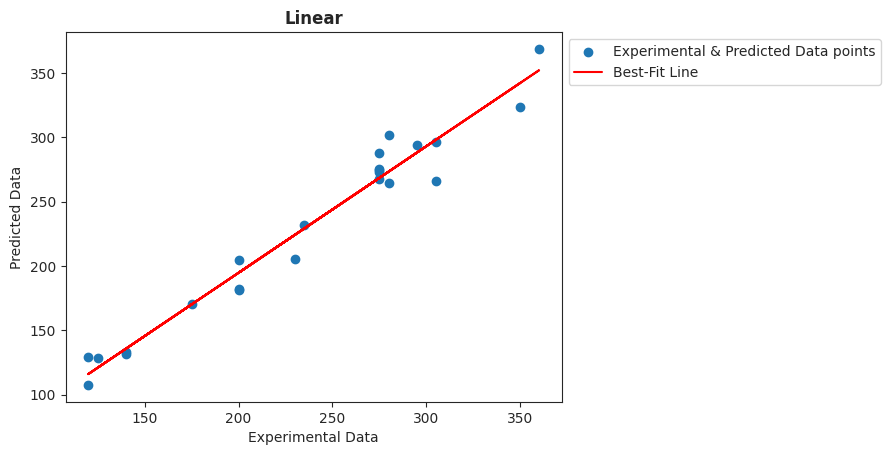

In [68]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x = np.array([275, 120, 360, 200, 350, 305, 230, 200, 275, 280, 305, 295, 275, 140, 175, 125, 200, 235, 280, 275, 275, 120, 140])
y_pred_values = np.array([274.57612696, 129.49681559, 368.58348715, 181.14973355,
       323.54457361, 296.01703003, 205.29732368, 204.39394339,
       272.77282019, 264.07897858, 265.74696654, 294.33395616,
       275.47950726, 131.79263809, 170.72534898, 128.5934353 ,
       182.05311385, 231.93526872, 302.09154061, 267.27483474,
       288.08779608, 107.64504795, 133.60058348])

data = {'x1': x, 'y_pred_linear_regression': y_pred_values}
df = pd.DataFrame(data)
# plt.figure(figsize=(8, 8))
plt.scatter(x='x1', y='y_pred_linear_regression', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Linear',  fontdict={'weight': 'bold'})
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('Linear Regression Model.pdf')
files.download('Linear Regression Model.pdf')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

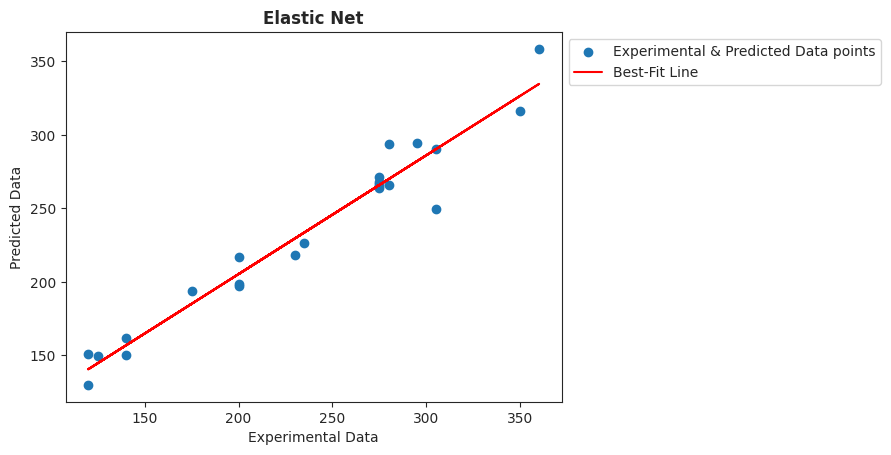

In [69]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x = np.array([275, 120, 360, 200, 350, 305, 230, 200, 275, 280, 305, 295, 275, 140, 175, 125, 200, 235, 280, 275, 275, 120, 140])
y_pred_values= np.array([264.97541597, 150.68180988, 358.49826539, 197.41801986,
       316.0926775 , 290.31076096, 217.93372424, 216.65492693,
       271.07385389, 266.08221387, 249.64622014, 294.39355765,
       266.25421327, 150.3416709 , 193.82620843, 149.40301257,
       198.69681717, 226.57292115, 293.75525648, 264.05205279,
       267.6043299 , 129.82596652, 161.77385456])
data = {'x1': x, 'y_pred_elastic_net': y_pred_values}
df = pd.DataFrame(data)
plt.scatter(x='x1', y='y_pred_elastic_net', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Elastic Net', fontdict={'weight': 'bold'})
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('Elastic Net.pdf')
files.download('Elastic Net.pdf')
plt.show()


In [ ]:
sns.set_style("ticks")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

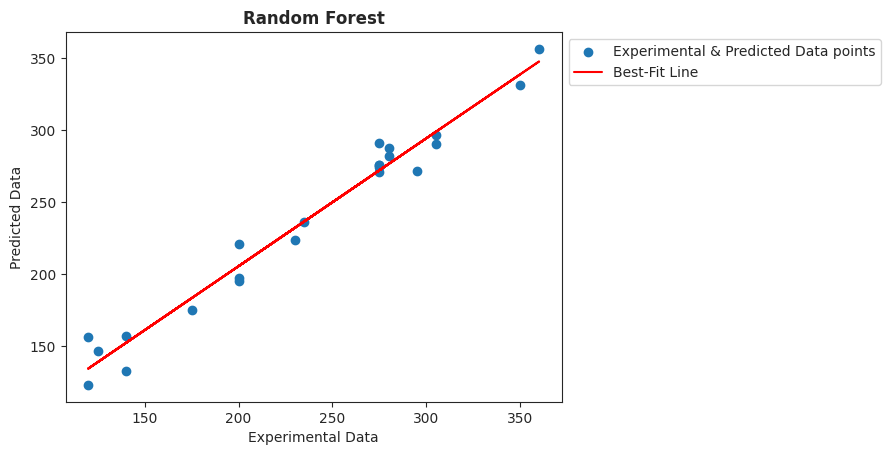

In [72]:
x = y_test
value_to_append = x.tolist()
emptyarray = np.empty(0)
x1 = np.append(emptyarray, value_to_append)
x1= np.array([275, 120, 360, 200, 350, 305, 230, 200, 275, 280, 305, 295, 275, 140, 175, 125, 200, 235, 280, 275, 275, 120, 140])
y_pred_values = np.array([275.45, 156.55, 356.25, 195.4 , 330.95, 296.45, 223.85, 221.15,
       271.05, 281.8 , 290.25, 271.25, 276.  , 133.  , 175.2 , 146.5 ,
       196.95, 236.2 , 287.2 , 274.  , 290.6 , 123.  , 156.95])
data = {'x1': x, 'y_pred_random_forest': y_pred_values}
df = pd.DataFrame(data)
plt.scatter(x='x1', y='y_pred_random_forest', data=df, label='Experimental & Predicted Data points')
fit_params = np.polyfit(x, y_pred_values, 1)
fit_line = np.poly1d(fit_params)
plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
plt.xlabel('Experimental Data')
plt.ylabel('Predicted Data')
plt.title('Random Forest', fontdict= {'weight' : 'bold'})
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('Random Forest.pdf')
files.download('Random Forest.pdf')
plt.show()

## **End**

In [ ]:
sns.set_style("ticks")

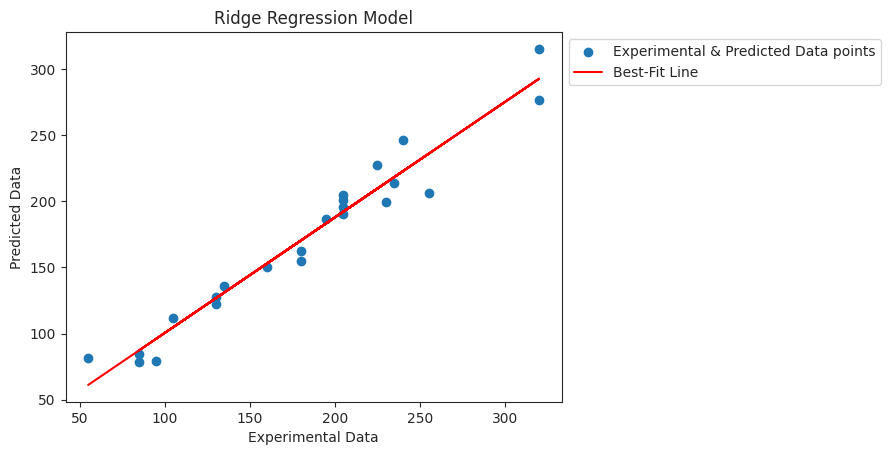

In [ ]:
# x = y_test
# value_to_append = x.tolist()
# emptyarray = np.empty(0)
# x1 = np.append(emptyarray, value_to_append)
# x1_values = np.array([205, 85, 320, 130, 320, 235, 180, 160, 195, 230, 205, 255, 205, 105, 135, 95, 130, 180, 240, 205, 225, 85, 55])
# y_pred_values = np.array([195.67401565,  84.51614887, 315.17119277, 122.40309891,
#        276.6639441 , 214.06750238, 155.22843174, 150.19476056,
#        186.27584073, 199.6342832 , 204.47065751, 206.62785191,
#        200.70768683, 111.62985149, 136.10771839,  79.48247769,
#        127.43677009, 162.25697279, 246.34040876, 190.64857404,
#        227.22864797,  78.80451866,  81.83604796])
# data = {'x1': x, 'y_pred_ridge_model': y_pred_values}
# df = pd.DataFrame(data)
# plt.scatter(x='x1', y='y_pred_ridge_model', data=df, label='Experimental & Predicted Data points')
# fit_params = np.polyfit(x, y_pred_values, 1)
# fit_line = np.poly1d(fit_params)
# plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
# plt.xlabel('Experimental Data')
# plt.ylabel('Predicted Data')
# plt.title('Ridge' , fontdict= {'weight' : 'bold'})
# # plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()


In [ ]:
sns.set_style("ticks")

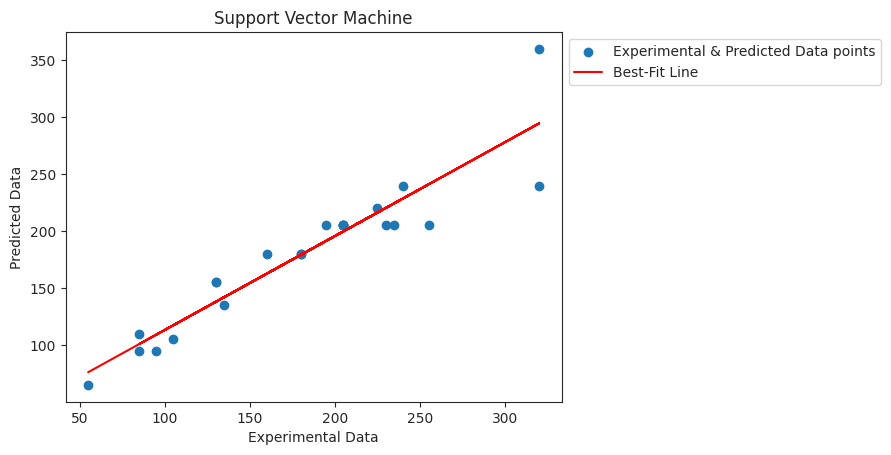

In [ ]:
# x = y_test
# value_to_append = x.tolist()
# emptyarray = np.empty(0)
# x1 = np.append(emptyarray, value_to_append)
# x1_values = np.array([205, 85, 320, 130, 320, 235, 180, 160, 195, 230, 205, 255, 205, 105, 135, 95, 130, 180, 240, 205, 225, 85, 55])
# y_pred_values = np.array([205, 110, 360, 155, 240, 205, 180, 180, 205, 205, 205, 205, 205,
#        105, 135,  95, 155, 180, 240, 205, 220,  95,  65])
# data = {'x1': x, 'y_pred_svm_model': y_pred_values}
# df = pd.DataFrame(data)
# plt.scatter(x='x1', y='y_pred_svm_model', data=df, label='Experimental & Predicted Data points')
# fit_params = np.polyfit(x, y_pred_values, 1)
# fit_line = np.poly1d(fit_params)
# plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
# plt.xlabel('Experimental Data')
# plt.ylabel('Predicted Data')
# plt.title('Support Vector Machine')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()


In [ ]:
sns.set_style("ticks")

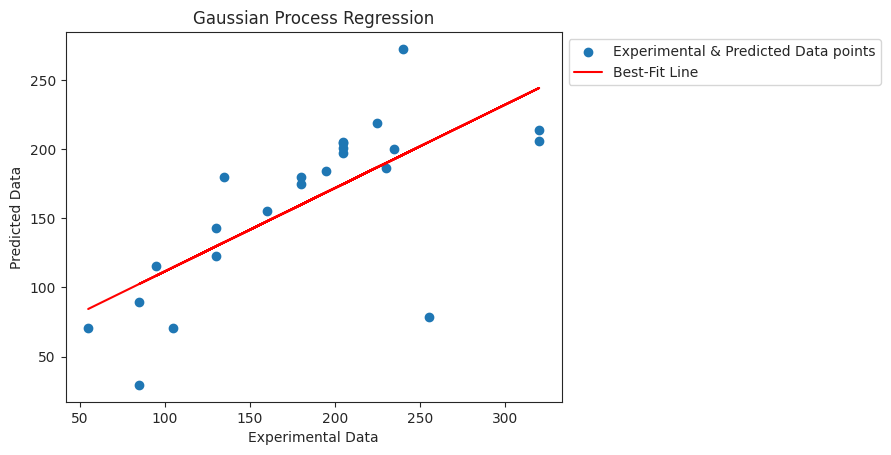

In [ ]:
# x = y_test
# value_to_append = x.tolist()
# emptyarray = np.empty(0)
# x1 = np.append(emptyarray, value_to_append)
# x1_values = np.array([205, 85, 320, 130, 320, 235, 180, 160, 195, 230, 205, 255, 205, 105, 135, 95, 130, 180, 240, 205, 225, 85, 55])
# y_pred_values = np.array([200.86602002,  89.3281031 , 206.04469284, 122.64863754,
#        213.47589737, 199.87934866, 179.46174088, 155.56203656,
#        184.03026429, 186.16426469, 204.77248501,  78.64697436,
#        197.01966535,  70.8840836 , 180.07326549, 115.57551697,
#        142.98184776, 174.80934528, 272.32232281, 204.51153664,
#        218.49777835,  29.5337507 ,  70.77291736])
# data = {'x1': x, 'y_pred_gpr_model': y_pred_values}
# df = pd.DataFrame(data)
# plt.scatter(x='x1', y='y_pred_gpr_model', data=df, label='Experimental & Predicted Data points')
# fit_params = np.polyfit(x, y_pred_values, 1)
# fit_line = np.poly1d(fit_params)
# plt.plot(x, fit_line(x), color='red', label='Best-Fit Line')
# plt.xlabel('Experimental Data')
# plt.ylabel('Predicted Data')
# plt.title('Gaussian Process Regression')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()
